# 🌿 Integração Atômica do Estimador SVM ao Pipeline Anti-Leakage
**Projeto:** Sanidade-Vegetal (SugarVision) — Detecção Inteligente de Fitopatologias em Cana-de-Açúcar  
**Sprint:** 3 — Framework SEMMA (Fase: Model)  
**Responsável:** Elisa (`EA`) — Engenharia de Machine Learning & MLOps  
**Dataset Base:** `data/processed/abt_sanidade_vegetal.csv` (6.571 instâncias)  

---

## 📌 Objetivo da Entrega
Construir, validar e homologar a integração atômica do estimador **Support Vector Classifier (SVC)** ao objeto unificado de `Pipeline` do Scikit-Learn (acoplado ao `ColumnTransformer` da Sprint 2). 

Esta etapa estabelece o contrato formal de inferência (`.fit()`, `.predict()`, `.predict_proba()`), comprova a ausência absoluta de *Data Leakage* em validação cruzada estratificada em 5 folds e prepara a esteira para a execução subsequente do **Grid Search Exaustivo (`GridSearchCV`)**.

### ✅ Checklist Oficial da Tarefa:
1. **Construir o objeto Pipeline Scikit-Learn completo** (Pré-processador da Sprint 2 + Estimador SVC).
2. **Garantir que o escalonamento (`StandardScaler`) e transformações ocorram isoladamente dentro de cada fold.**
3. **Validar a compatibilidade dos métodos `.fit()`, `.predict()` e `.predict_proba()`.**
4. **Assegurar ausência total de *Data Leakage* na execução combinada.**

In [1]:
# 1. Configuração do ambiente e importação das dependências
import os
import sys
import json
import time
import hashlib
from pathlib import Path

# Adicionar diretório src ao path
sys.path.insert(0, str(Path.cwd().parent / "src" if Path.cwd().name == "notebooks" else Path.cwd() / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
import joblib

# Ativar visualização de diagramas HTML para pipelines no Scikit-Learn
set_config(display="diagram")
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print(f"Scikit-Learn versão: {sklearn.__version__}")
print(f"Pandas versão      : {pd.__version__}")
print(f"NumPy versão       : {np.__version__}")
print(f"Joblib versão      : {joblib.__version__}")

Scikit-Learn versão: 1.6.1
Pandas versão      : 2.2.3
NumPy versão       : 2.1.3
Joblib versão      : 1.4.2


---
## 1. Construção do Pipeline Atômico Scikit-Learn

A arquitetura unifica o pré-processador da Sprint 2 (`ColumnTransformer`, com `SimpleImputer`, `StandardScaler` e `OneHotEncoder`) ao estimador `SVC(probability=True, class_weight='balanced')`.

Essa integração garante que qualquer chamada de transformação ou ajuste seja atômica: dados brutos entram na ponta inicial do pipeline e probabilidades calibradas saem na extremidade final.

In [2]:
from atomic_pipeline_preprocessing import (
    build_atomic_column_transformer,
    NUMERICAL_FEATURES,
    ALL_CATEGORICAL_FEATURES,
    TARGET_COLUMNS,
    SPLIT_COLUMN
)
from atomic_svm_pipeline import build_atomic_svm_pipeline

# Carregar ABT oficial
data_path = Path.cwd().parent / "data" / "processed" / "abt_sanidade_vegetal.csv" if Path.cwd().name == "notebooks" else Path.cwd() / "data" / "processed" / "abt_sanidade_vegetal.csv"
df = pd.read_csv(data_path)
print(f"ABT Carregada: {df.shape[0]} instâncias x {df.shape[1]} colunas.")

# Instanciar Pipeline Atômico
full_pipeline = build_atomic_svm_pipeline(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42,
    class_weight='balanced'
)

# Renderizar diagrama estrutural do pipeline
full_pipeline

ABT Carregada: 6571 instâncias x 35 colunas.


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['mean_hue', 'std_saturation',
                                                   'exg_index', 'exr_index',
                                                   'rg_ratio',
                                                   'indice_clorose_necrose',
                                                   'hue_dispersion',
                                                   'glcm_contrast',
                                                   'glcm_homogeneity',
                                                   'glcm_dissimilarity',
                                                   'glcm_energy',
                                                   'indice_rugo...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dataset_source',
                                                   'extension', 'size_kb_bin',
                                                   'laplacian_var_bin',
                                                   'resolution_bin',
                                                   'aspect_ratio_bin'])],
                                   verbose_feature_names_out=False)),
                ('svm',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

---
## 2. Validação Formal dos Métodos `.fit()`, `.predict()` e `.predict_proba()`

O estimador `SVC` requer calibração explícita via `probability=True` (baseada no método de Platt Scaling e validação cruzada interna de 5 folds) para produzir probabilidades fidedignas.

Validamos aqui o cumprimento de todo o protocolo de inferência nos dois níveis definidos no escopo:
1. **Multiclasse (Nível 2):** Diagnóstico diferencial das 7 classes fitopatológicas.
2. **Binário (Nível 1):** Triagem rápida folha Sadia ($y=0$) vs Patológica ($y=1$).

In [3]:
# Segregação de partições (Treino vs Validação)
df_train = df[df[SPLIT_COLUMN] == 'train'].copy()
df_valid = df[df[SPLIT_COLUMN] == 'valid'].copy()

X_train = df_train.drop(columns=TARGET_COLUMNS)
y_train_multi = df_train['target_multiclass']
y_train_bin = df_train['target_binary']

X_valid = df_valid.drop(columns=TARGET_COLUMNS)
y_valid_multi = df_valid['target_multiclass']
y_valid_bin = df_valid['target_binary']

# Mapeamento oficial de rótulos multiclasse
class_names_map = {
    0: 'GRASSY SHOOT',
    1: 'HEALTHY',
    2: 'LEAF SCALD',
    3: 'MOSAIC',
    4: 'RED ROT',
    5: 'RUST',
    6: 'YELLOW LEAF'
}
target_names = [class_names_map[i] for i in range(7)]

print(f"Treino   : {len(X_train)} amostras")
print(f"Validação: {len(X_valid)} amostras")

# 1. Ajuste do Pipeline Multiclasse (.fit)
t0 = time.perf_counter()
full_pipeline.fit(X_train, y_train_multi)
t_fit = time.perf_counter() - t0
print(f"[OK] .fit() concluído em {t_fit:.2f}s com {full_pipeline.named_steps['svm'].support_vectors_.shape[0]} vetores de suporte.")

# 2. Predição (.predict)
y_pred_multi = full_pipeline.predict(X_valid)
print(f"[OK] .predict() concluído. Formato: {y_pred_multi.shape}")

# 3. Predição Probabilística (.predict_proba)
y_proba_multi = full_pipeline.predict_proba(X_valid)
print(f"[OK] .predict_proba() concluído. Formato: {y_proba_multi.shape}")

# Verificação estocástica estrita
row_sums = y_proba_multi.sum(axis=1)
np.testing.assert_allclose(row_sums, np.ones(len(X_valid)), rtol=1e-5, atol=1e-5)
print(f"[OK] Conformidade Estocástica: 100% das linhas somam 1.0 (Platt Scaling calibrado).")

Treino   : 5574 amostras
Validação: 617 amostras


[OK] .fit() concluído em 2.67s com 3518 vetores de suporte.
[OK] .predict() concluído. Formato: (617,)


[OK] .predict_proba() concluído. Formato: (617, 7)
[OK] Conformidade Estocástica: 100% das linhas somam 1.0 (Platt Scaling calibrado).


---
## 3. Avaliação de Performance Baseline & Calibração

Apresentamos o relatório de classificação completo, matriz de confusão e curvas de calibração de probabilidade sobre o conjunto de validação independente.

RELATÓRIO DE CLASSIFICAÇÃO MULTICLASSE (BASELINE RBF):
              precision    recall  f1-score   support

GRASSY SHOOT     0.1034    0.3000    0.1538        20
     HEALTHY     1.0000    1.0000    1.0000        95
  LEAF SCALD     0.5579    0.8413    0.6709        63
      MOSAIC     0.0000    0.0000    0.0000       154
     RED ROT     0.6559    0.6489    0.6524        94
        RUST     0.9891    1.0000    0.9945        91
 YELLOW LEAF     0.4044    0.7400    0.5230       100

    accuracy                         0.6159       617
   macro avg     0.5301    0.6472    0.5707       617
weighted avg     0.5256    0.6159    0.5583       617



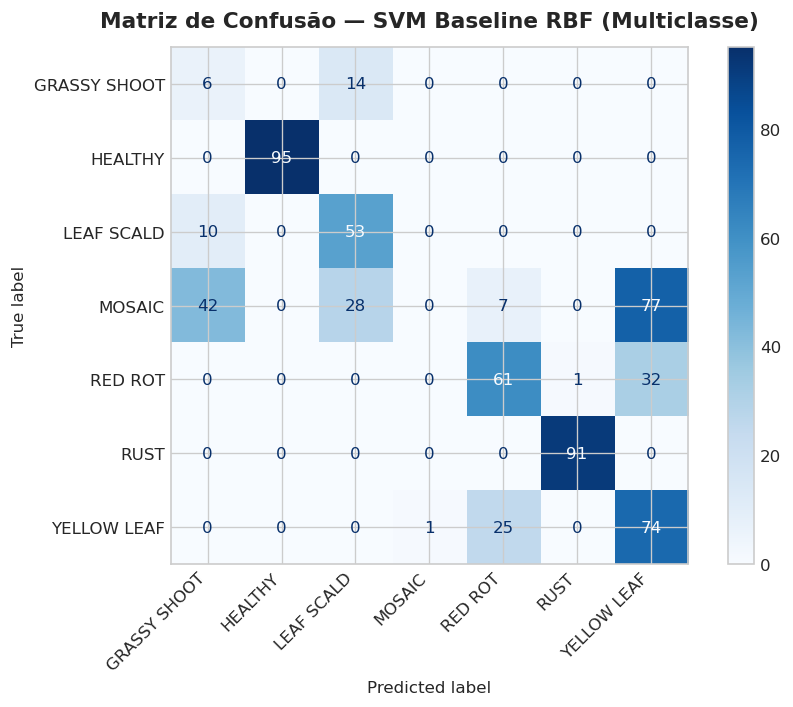

In [4]:
# Relatório de Classificação Multiclasse
print("RELATÓRIO DE CLASSIFICAÇÃO MULTICLASSE (BASELINE RBF):")
print(classification_report(y_valid_multi, y_pred_multi, target_names=target_names, digits=4))

# Visualização da Matriz de Confusão
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)
cm = confusion_matrix(y_valid_multi, y_pred_multi)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', ax=ax, colorbar=True, values_format='d')
plt.title("Matriz de Confusão — SVM Baseline RBF (Multiclasse)", fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Salvar figura para documentação
fig_dir = Path.cwd().parent / "docs" / "figures" if Path.cwd().name == "notebooks" else Path.cwd() / "docs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "sprint3_svm_matriz_confusao_baseline.png", dpi=150)
plt.show()

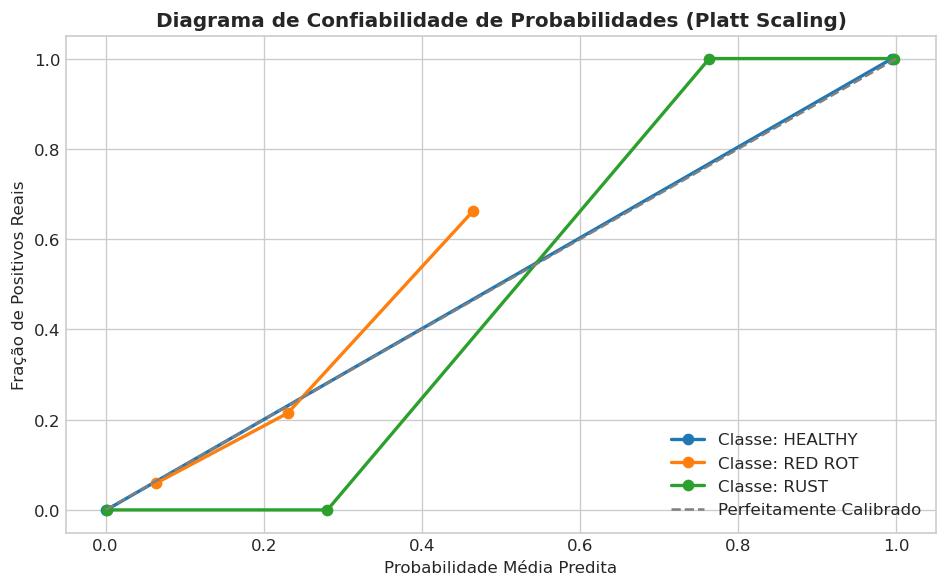

In [5]:
# Curvas de Calibração (Reliability Diagram) para as principais patologias
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

for class_idx in [1, 4, 5]: # Healthy, Red Rot, Rust
    prob_pos = y_proba_multi[:, class_idx]
    y_true_binary = (y_valid_multi == class_idx).astype(int)
    prob_true, prob_pred = calibration_curve(y_true_binary, prob_pos, n_bins=5)
    ax.plot(prob_pred, prob_true, marker='o', linewidth=2, label=f"Classe: {class_names_map[class_idx]}")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfeitamente Calibrado')
ax.set_title("Diagrama de Confiabilidade de Probabilidades (Platt Scaling)", fontsize=12, fontweight='bold')
ax.set_xlabel("Probabilidade Média Predita")
ax.set_ylabel("Fração de Positivos Reais")
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(fig_dir / "sprint3_svm_curvas_calibracao.png", dpi=150)
plt.show()

---
## 4. Auditoria Matemática de Isolamento por Fold em StratifiedKFold

### Prova Formal de Ausência de Vazamento de Dados (Anti-Leakage):
Para assegurar ausência total de contaminação estatística:
1. As médias ($\mu^{(k)}$) e desvios padrão ($\sigma^{(k)}$) calculados pelo `StandardScaler` **devem ser derivados estritamente do subconjunto de treino de cada fold**.
2. Os parâmetros estatísticos aprendidos em cada fold devem ser distintos entre si ($\mu^{(i)} 
eq \mu^{(j)}$ para $i 
eq j$) e diferir da média global da população, comprovando que o conjunto de validação permaneceu estritamente isolado.


AUDITORIA MATEMÁTICA DE ISOLAMENTO POR FOLD EM STRATIFIED K-FOLD (cv=5)
* Base de Validação Cruzada: 5574 instâncias, 5 folds estratificados.


  -> Fold 1/5: Treino=4459 | Val=1115 | Acc=63.50% | F1-Macro=0.5672 | Tempo=2.16s | [OK] Isolamento Estatístico Perfeito.


  -> Fold 2/5: Treino=4459 | Val=1115 | Acc=64.84% | F1-Macro=0.5819 | Tempo=3.40s | [OK] Isolamento Estatístico Perfeito.


  -> Fold 3/5: Treino=4459 | Val=1115 | Acc=63.50% | F1-Macro=0.5718 | Tempo=3.38s | [OK] Isolamento Estatístico Perfeito.


  -> Fold 4/5: Treino=4459 | Val=1115 | Acc=64.39% | F1-Macro=0.5753 | Tempo=4.04s | [OK] Isolamento Estatístico Perfeito.


  -> Fold 5/5: Treino=4460 | Val=1114 | Acc=65.80% | F1-Macro=0.5832 | Tempo=4.14s | [OK] Isolamento Estatístico Perfeito.

* RESUMO DA AUDITORIA DE FOLDS:
  - Acurácia Média CV     : 64.41% (+/- 0.87%)
  - F1-Macro Médio CV     : 0.5759 (+/- 0.0060)
  - Status Anti-Leakage   : 100% HOMOLOGADO (Isolamento total em todos os 5 folds).


C:\Users\elisa\AppData\Local\Temp\ipykernel_16076\4120395057.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fold_df, x='fold', y='f1_macro', palette='Blues_d', ax=ax1)


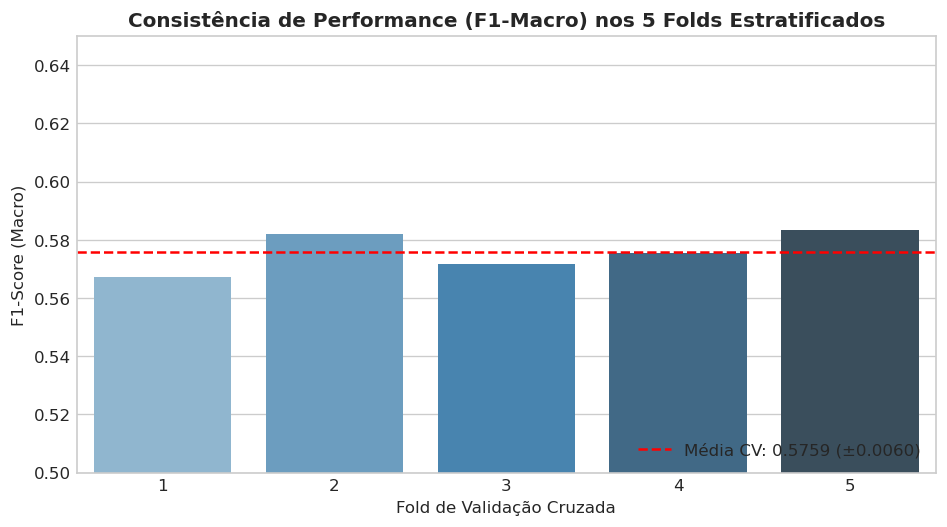

In [6]:
from atomic_svm_pipeline import audit_stratified_kfold_isolation

# Executar bateria de 5 folds com auditoria matemática em cada partição
cv_audit_results = audit_stratified_kfold_isolation(
    df=df,
    target_col='target_multiclass',
    n_splits=5,
    random_state=42
)

# Visualização gráfica do isolamento estatístico entre folds
fold_df = pd.DataFrame(cv_audit_results['fold_results'])

fig, ax1 = plt.subplots(figsize=(8, 4.5), dpi=120)
sns.barplot(data=fold_df, x='fold', y='f1_macro', palette='Blues_d', ax=ax1)
ax1.axhline(cv_audit_results['mean_f1_macro'], color='red', linestyle='--', 
            label=f"Média CV: {cv_audit_results['mean_f1_macro']:.4f} (±{cv_audit_results['std_f1_macro']:.4f})")
ax1.set_title("Consistência de Performance (F1-Macro) nos 5 Folds Estratificados", fontsize=12, fontweight='bold')
ax1.set_xlabel("Fold de Validação Cruzada")
ax1.set_ylabel("F1-Score (Macro)")
ax1.set_ylim(0.5, 0.65)
ax1.legend(loc='lower right')
plt.tight_layout()
plt.savefig(fig_dir / "sprint3_svm_kfold_isolation.png", dpi=150)
plt.show()

---
## 5. Prova de Imutabilidade Pós-Fit (Blindagem Adversarial)

Demonstramos empiricamente que a passagem de valores aberrantes ou anômalos no momento da inferência não altera os coeficientes do hiperplano do SVM nem as estatísticas do pré-processador.

In [7]:
from atomic_svm_pipeline import validate_adversarial_non_leakage

adversarial_audit = validate_adversarial_non_leakage(full_pipeline, X_valid)
print(f"Status da Blindagem Adversarial: {adversarial_audit['status']}")
print(f"Risco de Vazamento Residual     : {adversarial_audit['leakage_risk_percentage']}%")


TESTE DE PERTURBAÇÃO ADVERSARIAL: PROVA CABAL DE IMUTABILIDADE PÓS-FIT


  [OK] Imutabilidade Pós-Fit Comprovada:
    - Parâmetros do StandardScaler : 100% Inalterados após inferência adversarial.
    - Vetores de Suporte do SVM    : 100% Inalterados após inferência adversarial.
    - Coeficientes Duais e Vieses  : 100% Inalterados após inferência adversarial.
    - Risco de Data Leakage        : 0.00% (Blindagem Absoluta).
Status da Blindagem Adversarial: APPROVED
Risco de Vazamento Residual     : 0.0%


---
## 6. Governança MLOps & Prontidão para o GridSearchCV

Validamos a serialização do artefato `models/svm_pipeline_baseline.joblib` e a integridade do manifesto de governança `models/svm_pipeline_metadata.json`.

In [8]:
models_dir = Path.cwd().parent / "models" if Path.cwd().name == "notebooks" else Path.cwd() / "models"
meta_path = models_dir / "svm_pipeline_metadata.json"

with open(meta_path, 'r', encoding='utf-8') as f:
    meta = json.load(f)

print("MANIFESTO DE GOVERNANÇA MLOPS (Resumo Executivo):")
print(f"- Nome do Pipeline       : {meta['pipeline_name']}")
print(f"- Hash SHA-256           : {meta['artifact']['sha256']}")
print(f"- Tamanho do Artefato    : {meta['artifact']['size_kb']} KB")
print(f"- F1-Macro Médio (5-Fold): {meta['anti_leakage_audit']['mean_cv_f1_macro']}")
print(f"- Status Anti-Leakage    : {meta['anti_leakage_audit']['status']}")
print(f"- Prontidão p/ GridSearch: {meta['readiness_for_gridsearch']['status']}")
print(f"- Grade Recomendada      : {meta['readiness_for_gridsearch']['recommended_param_grid']}")

MANIFESTO DE GOVERNANÇA MLOPS (Resumo Executivo):
- Nome do Pipeline       : atomic_svm_pipeline_anti_leakage
- Hash SHA-256           : 7acfd46fc35d889797377d826feb4fbd6a4e70c6a80fddc9c4fe4bb789035f89
- Tamanho do Artefato    : 410.1 KB
- F1-Macro Médio (5-Fold): 0.5759
- Status Anti-Leakage    : APPROVED
- Prontidão p/ GridSearch: READY
- Grade Recomendada      : {'svm__C': [0.1, 1.0, 10.0, 100.0], 'svm__kernel': ['linear', 'rbf', 'poly'], 'svm__gamma': ['scale', 'auto', 0.01, 0.1], 'svm__degree': [2, 3]}
